## <span>Performance Assessment | D208 | Task 2: LOGISTIC REGRESSION FOR PREDICTIVE MODELING</span>
### Name: Johan Johnson (jjo2211@wgu.edu)

### **A1. Question**
Which customers are most likely to leave the telecom company, and why? What features are especially important in terms of customer churn?

### **A2. Goals and Objectives**
Stakeholders in the organization will benefit from knowing with some certainty which customers are more 
likely to churn and which aren't. Stakeholders will be able to get answers to their inquiries and make better business 
decisions as a consequence of statistical analysis.

### **B1. Assumptions**

The Bernoulli Distribution is used in logistic regression, where the predicted values are limited to a range of nominal values such as "Yes" or "No".
Logistic Regression forecasts the likelihood of specific events rather than the outcome itself. Logistic Regression is the logarithm of one's chances of success.

### **B2. Benefits of using Python**

This project will be supported by Jupyter notebook, and the analysis will be done in Python. Python is a programming language that focuses on readability and cross-platform compatibility. It is fast and well-suited for large-scale machine learning deployment as compared to other programming languages like R.

### **B3: Explanation on why logistic regression is an appropriate technique**

The categorical dependent variable is predicted using a set of independent variables in Logistic Regression. We find the S-curve by which we may classify the data and forecast the values of categorical variables. We want to determine the likelihood of customer turnover for certain consumers based on a collection of independent variables. We will obtain a better understanding of increasing churn probability by understanding how the predictor variables affect the overall target variable.

### **C1: Data Goals**

1. Import the dataset into Python using the read csv command, as well as the necessary libraries for the analysis.
2. To have a better grasp of the dataset, look at the data structure. Find outliers through the use of boxplots and impute missing data with either mean, median or mode. 
3. The dependent variable will be "Churn", which will also be the categorical binary target variable. Other category predictor factors were discovered in the dataset after further inspection. 
4. Finally, discrete ordinal predictor variables from "Item 1" to "Item 8" from the dataset were renamed according to the data dictionary inorder for the reader to better understand the features.


### **C2. Summary Statistics**

There were 50 columns and 10,000 records in the imported dataset. User IDs and demographic category variables were eliminated. Before doing the regression analysis, all other binary categorical variables were encoded as 1 or 0. There were 33 numerical independent predictor variables and 1 dependent variable remained at this point (34 total columns). Prior to import, the churn dataset had been cleaned, and there appeared to be no null or missing values in the dataset. Although "Outage sec per week" and "MonthlyCharge" appear to have normal distributions, "Bandwidth GB Year" and "Tenure" appear to have bimodal distributions. The average age of this dataset is 53.08 years, with a standard deviation of 20.70. The average household income in the United States is $39806.93. A particular household had a maximum of ten children. The average annual consumption of gigabytes per family was 3,392 GB. The target variable, "Churn," will be the dependant variable for this analysis.

### **C3. Steps to Prepare Data**

1. Import dataset and rename survey columns according to data dictionary
2. Understand data structure and checkout summary statistics
3. Remove all demographic categorical factors as well as any other columns that are irrelevant to the logistic regression analysis.
4. Look for any missing values and impute missing values with mean, mode or median. 
5. Convert binary category data points to numerical values, then store them in dummy variables. Remove the dataframe's original categorical columns and save these new variables for later analysis.
6. Use histograms to analyze univariate visualizations and scatterplots to examine bivariate visuals.
7. The produced dataset will be exported and made accessible as "newlogisticchurn.csv" in the form of a spreadsheet.

In [1]:
#Import Libraries 
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

import sklearn 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
#Import dataset by using the read_csv command
newchurns = pd.read_csv('churn_clean.csv')

In [3]:
#Rename survey columns/variables
newchurns.rename(columns = {'Item1':'ResponsesFromTheCompany','Item2':'FixingOftime',
'Item3':'ReplacementsofTime','Item4':'CompanysReliability','Item5':'DifferentOptions',
'Item6':'RespectfulnessResponse','Item7':'Court.Exchange','Item8':'ListeningActively!'},
inplace=True)

In [4]:
df = newchurns.columns
newchurns.shape


(10000, 50)

In [5]:
#Drop demographic categorical and other irrelevant variables
newchurns= newchurns.drop(columns=['Population','PaymentMethod', 'CaseOrder', 'UID', 'County', 'City', 'Area', 'Zip', 'Lat',
'State', 'Interaction', 'Lng', 'TimeZone', 'Job', 'Marital','Customer_id'])

In [ ]:
# any null or missing values?
#Looks like there are no null values since the churn dataset is cleaned prior
anyvalues= newchurns.isnull().sum()
print(anyvalues)

In [6]:
#Encode categorical variables into numerical values 
newchurns['EncodedGender'] = [1 if i == 'Male' else 0 for  i in newchurns['Gender']]
newchurns['EncodedChurn'] = [1 if i == 'Yes' else 0 for i in newchurns['Churn']]
newchurns['EncodedTechie'] = [1 if i == 'Yes' else 0 for i in newchurns['Techie']]
newchurns['EncodedContract'] = [1 if i == 'One year' else 0 for i in newchurns['Contract']]
newchurns['EncodedPort_modem'] = [1 if i == 'Yes' else 0 for i in newchurns['Port_modem']]
newchurns['EncodedTablet'] = [1 if i == 'Yes' else 0 for i in newchurns['Tablet']]
newchurns['EncodedInternetService'] = [1 if i == 'DSL' else 0 for i in newchurns['InternetService']]
newchurns['EncodedPhone'] = [1 if i == 'Yes' else 0 for i in newchurns['Phone']]
newchurns['EncodedMultiple'] = [1 if i == 'Yes' else 0 for i in newchurns['Multiple']]
newchurns['EncodedOnlineSecurity'] = [1 if i == 'Yes' else 0 for i in newchurns['OnlineSecurity']]
newchurns['EncodedOnlineBackup'] = [1 if i == 'Yes' else 0 for i in newchurns['OnlineBackup']]
newchurns['EncodedDeviceProtection'] = [1 if i == 'Yes' else 0 for i in newchurns['DeviceProtection']]
newchurns['EncodedTechSupport'] = [1 if i == 'Yes' else 0 for i in newchurns['TechSupport']]
newchurns['EncodedStreamingTV'] = [1 if i == 'Yes' else 0 for i in newchurns['StreamingTV']]
newchurns['EncodedStreamingMovies'] = [1 if i == 'Yes' else 0 for i in newchurns['StreamingMovies']]
newchurns['EncodedPaperlessBilling'] = [1 if i == 'Yes' else 0 for i in newchurns['PaperlessBilling']]

In [7]:
churns_rate= newchurns.drop(columns=['StreamingMovies','PaperlessBilling','Gender', 'Churn',  'Tablet', 'Phone', 'InternetService', 'DeviceProtection', 'Multiple', 'OnlineSecurity', 
'OnlineBackup','TechSupport','Port_modem', 'StreamingTV', 'Contract', 'Techie'])
churns_rate.describe() 

,Children,Age,Income,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Tenure,MonthlyCharge,Bandwidth_GB_Year,...,EncodedInternetService,EncodedPhone,EncodedMultiple,EncodedOnlineSecurity,EncodedOnlineBackup,EncodedDeviceProtection,EncodedTechSupport,EncodedStreamingTV,EncodedStreamingMovies,EncodedPaperlessBilling
count,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2.0877,53.078400,39806.926771,10.001848,12.016000,0.994200,0.398000,34.526188,172.624816,3392.341550,...,0.346300,0.906700,0.460800,0.357600,0.450600,0.438600,0.375000,0.492900,0.489000,0.588200
std,2.1472,20.698882,28199.916702,2.976019,3.025898,0.988466,0.635953,26.443063,42.943094,2185.294852,...,0.475814,0.290867,0.498486,0.479317,0.497579,0.496241,0.484147,0.499975,0.499904,0.492184
min,0.0000,18.000000,348.670000,0.099747,1.000000,0.000000,0.000000,1.000259,79.978860,155.506715,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.0000,35.000000,19224.717500,8.018214,10.000000,0.000000,0.000000,7.917694,139.979239,1236.470827,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.0000,53.000000,33170.605000,10.018560,12.000000,1.000000,0.000000,35.430507,167.484700,3279.536903,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,3.0000,71.000000,53246.170000,11.969485,14.000000,2.000000,1.000000,61.479795,200.734725,5586.141370,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,10.0000,89.000000,258900.700000,21.207230,23.000000,7.000000,6.000000,71.999280,290.160419,7158.981530,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
churns = churns_rate[['Children', 'Age', 'Income', 'Outage_sec_perweek', 'Email', 'Contacts','Yearly_equip_failure', 'Bandwidth_GB_Year', 'Tenure', 'MonthlyCharge',
'ResponsesFromTheCompany', 'FixingOftime', 'ReplacementsofTime', 'CompanysReliability',
'DifferentOptions', 'RespectfulnessResponse', 'Court.Exchange', 'ListeningActively!',
'EncodedGender', 'EncodedTechie', 'EncodedContract',
'EncodedPort_modem', 'EncodedTablet', 'EncodedInternetService',
'EncodedPhone', 'EncodedMultiple', 'EncodedOnlineSecurity',
'EncodedOnlineBackup', 'EncodedDeviceProtection', 'EncodedTechSupport',
'EncodedStreamingTV', 'EncodedStreamingMovies',
'EncodedPaperlessBilling', 'EncodedChurn']]

### **C4. Univariate and Bivariate Visualizations**

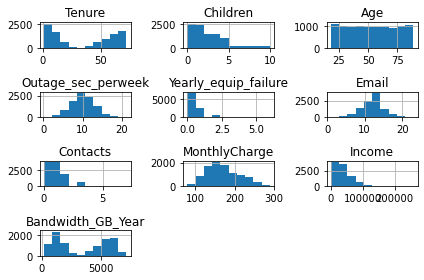

In [10]:
#univariate stats (Visualizations for each continous variables)
churns[['Tenure', 'Children', 'Age', 'Outage_sec_perweek', 'Yearly_equip_failure','Email', 'Contacts', 'MonthlyCharge', 'Income', 'Bandwidth_GB_Year']].hist()
plt.tight_layout()

C:\Users\HP\miniconda3\envs\ds\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


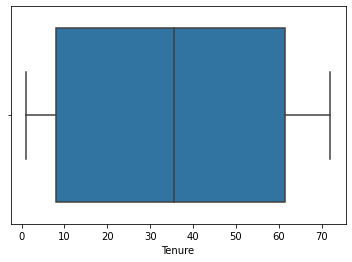

In [11]:
#Checking to see if there are any outliers by using boxplot
sns.boxplot('Tenure', data= churns)
plt.show()

C:\Users\HP\miniconda3\envs\ds\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


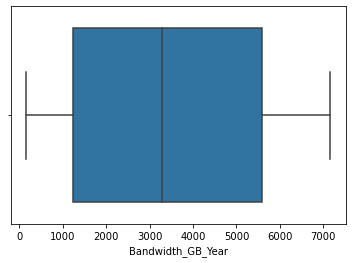

In [13]:
sns.boxplot('Bandwidth_GB_Year', data = churns)
plt.show()

**There don't appear to be any outliers. It appears that the dataset has been cleansed previously.**

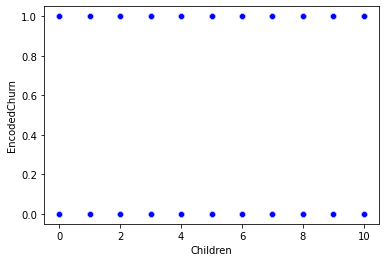

In [14]:
#bivariate stats
sns.scatterplot(x=churns['Children'], y=churns['EncodedChurn'], color='blue')
plt.show();

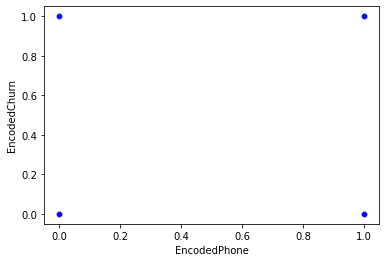

In [15]:
sns.scatterplot(x=churns['EncodedPhone'], y=churns['EncodedChurn'], color='blue')
plt.show();

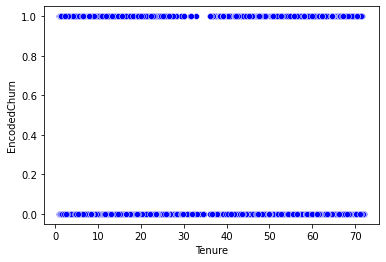

In [19]:
sns.scatterplot(x=churns['Tenure'], y=churns['EncodedChurn'], color='blue')
plt.show();

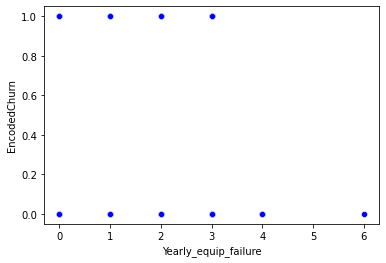

In [20]:
sns.scatterplot(x=churns['Yearly_equip_failure'], y=churns['EncodedChurn'], color='blue')
plt.show();

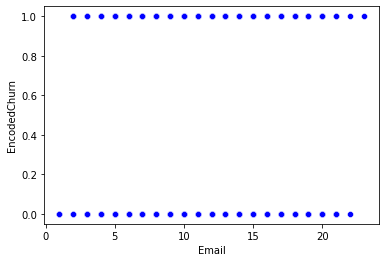

In [22]:
sns.scatterplot(x=churns['Email'], y=churns['EncodedChurn'], color='blue')
plt.show();

**These scatterplots indicate that there is no link between customer churn and any of our ongoing user data points**

### **C5. Prepared Dataset**

In [26]:
churns.to_csv('newlogisticchurn.csv')
newchurns = pd.read_csv('newlogisticchurn.csv')

In [27]:
newchurns.shape

(10000, 35)

### **D1. Initial Logistic Regression Model**

In [33]:
from statsmodels.formula.api import logit
import statsmodels.api as sm

In [34]:
#Logistic Regression Results (Dummy variables are not included for the predictor variables)
newchurns['intercept'] = 1
churn_rate = sm.Logit(newchurns['EncodedChurn'], newchurns[['Children', 'Age', 'Income', 
'Outage_sec_perweek', 'Email', 'Contacts','Yearly_equip_failure', 'Tenure', 'Bandwidth_GB_Year', 'MonthlyCharge', 'ResponsesFromTheCompany', 'FixingOftime', 'ReplacementsofTime', 'CompanysReliability',
'DifferentOptions', 'RespectfulnessResponse', 'Court.Exchange', 'ListeningActively!', 'intercept']]).fit()
print(churn_rate.summary())

Optimization terminated successfully.
         Current function value: 0.319573
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:           EncodedChurn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9981
Method:                           MLE   Df Model:                           18
Date:                Thu, 21 Oct 2021   Pseudo R-squ.:                  0.4473
Time:                        22:59:19   Log-Likelihood:                -3195.7
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Children                   -0.0980      0.016     -6.318      0.000      -0.128   

In [35]:
#All predictor variables are included in the Logistic Regression Analysis (Includes the dummy variables)
newchurns['intercept'] = 1
churn_rate = sm.Logit(newchurns['EncodedChurn'], newchurns[['Children', 'Age', 'Income', 
'Outage_sec_perweek', 'Email', 'Contacts','Yearly_equip_failure', 'Tenure', 'MonthlyCharge',
'ResponsesFromTheCompany', 'FixingOftime', 'ReplacementsofTime', 'CompanysReliability',
'DifferentOptions', 'RespectfulnessResponse', 'Court.Exchange', 'ListeningActively!',
'EncodedGender', 'Bandwidth_GB_Year', 'EncodedTechie', 'EncodedContract',
'EncodedPort_modem', 'EncodedTablet', 'EncodedInternetService',
'EncodedPhone', 'EncodedMultiple', 'EncodedOnlineSecurity',
'EncodedOnlineBackup', 'EncodedDeviceProtection', 'EncodedTechSupport',
'EncodedStreamingTV', 'EncodedStreamingMovies',
'EncodedPaperlessBilling', 'intercept']]).fit()

print(churn_rate.summary())

Optimization terminated successfully.
         Current function value: 0.277912
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:           EncodedChurn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9966
Method:                           MLE   Df Model:                           33
Date:                Thu, 21 Oct 2021   Pseudo R-squ.:                  0.5194
Time:                        23:00:10   Log-Likelihood:                -2779.1
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Children                   -0.2835      0.051     -5.581      0.000      -0.383   

### **D1 Initial Logistic Regression Model Equation**

According to the table above, psuedo R squared value increased from .4473 to.5194 after the dummy variables were added to the continuous variables. In this case, the model with the larger pseudo R-squared (**when encoded categorical values were included**) is the one that best predicts the outcome.
y = -4.06 + -0.28*X<sub>1</sub> + 0.0314*X<sub>2</sub> + 0*X<sub>3</sub> + -0.0040*X<sub>4</sub> + -0.0034*X<sub>5</sub> + 0.0464*X<sub>6</sub>+ -0.0340*X<sub>7</sub> + -0.8415*X<sub>8</sub> + 0.0029*X<sub>9</sub> + -0.0099*X<sub>10</sub> -0.0103*X<sub>11</sub> + 0.0191*X<sub>12</sub> + -0.0425*X<sub>13</sub> + -0.0374*X<sub>14</sub> -0.0052*X<sub>15</sub> + -0.0292*X<sub>16</sub> + 0.003*X<sub>17</sub> -0.4064*X<sub>18</sub> + 0.0091*X<sub>19</sub> + .8439*X<sub>20</sub> + -2.1030*X<sub>21</sub> + 0.0996*X<sub>22</sub> -0.0451*X<sub>23</sub> + -2.7222*X<sub>24</sub> + -0.2121*X<sub>25</sub> + 0.4999*X<sub>26</sub> -0.8800*X<sub>27</sub> + -0.2932*X<sub>28</sub> + -.4440*X<sub>29</sub> + .1500*X<sub>30</sub> + 0.0875*X<sub>31</sub> + 0.6765*X<sub>32</sub> + 0.0908*X<sub>33</sub> 

### **D2 Justification for Model Reduction**

One model selection strategy is the **backward-elimination strategy**. The approach begins with a model that incorporates all possible predictor variables. Variables are excluded from the model ONE AT A TIME until only those with statistically significant p values remain (until the P values are smaller than the alpha value) (0.05)
1. ActiveListening has the highest p value. Delete the "ActiveListening" column and refit the model
2. Continue the process until other variables with p values greater than the alpha value (0.05) needs to be removed. 
3. After refitting the model, we can see that EncodedTechSupport and MonthlyCharge still needs to be removed. After the removal process, see if there are any more p values that are greater than the alpha value.
4. Run the seaborn heatmap to see any correlation

### **D3. Reduced Regression Model**

In [36]:
#Includes the refined predictor variables.
newchurns['intercept'] = 1
churn_rate = sm.Logit(newchurns['EncodedChurn'], newchurns[['Children', 'Age', 'Tenure',
'EncodedGender', 'Bandwidth_GB_Year', 'EncodedTechie', 'EncodedContract',
'EncodedInternetService','EncodedMultiple', 'EncodedOnlineSecurity',
'EncodedOnlineBackup', 'EncodedDeviceProtection', 'EncodedStreamingMovies','intercept']]).fit()

print(churn_rate.summary())

Optimization terminated successfully.
         Current function value: 0.278942
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:           EncodedChurn   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9986
Method:                           MLE   Df Model:                           13
Date:                Thu, 21 Oct 2021   Pseudo R-squ.:                  0.5176
Time:                        23:00:20   Log-Likelihood:                -2789.4
converged:                       True   LL-Null:                       -5782.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Children                   -0.3118      0.019    -16.152      0.000      -0.350   

**Reduced Logistic Model Regression Equation**

y = -4.381 + -0.311*X<sub>1</sub> + 0.0344*X<sub>2</sub> + -0.9144*X<sub>3</sub> + -0.4591*X<sub>4</sub> + -0.0100*X<sub>5</sub> + 0.843*X<sub>6</sub>+ -2.0981*X<sub>7</sub> + -3.1186*X<sub>8</sub> + 0.5248*X<sub>9</sub> + -0.9319*X<sub>10</sub> -0.3146*X<sub>11</sub> -0.4808*X<sub>12</sub> + 0.6269*X<sub>13</sub>

### **E1. Comparision of different models**

Despite halving the number of variables, the second model still explains 51.76 percent of variance, as proven by the pseudo R. The sign of the coefficient reflects whether the link between each independent and dependent variable is positive or negative. A positive coefficient suggests that as the value of the independent variable grows, the mean of the dependent variable tends to climb as well. A negative coefficient suggests that as the independent variable rises, the dependent variable tends to fall.
For example, the longer a consumer stays with a company or whether they have a device protection add-on and internet service, the less likely they are to churn. Stakeholders can improve customer experience and help customers grasp everything the firm is providing them by understanding the inverse correlations between certain inverse variables and the target variable.



**Development of Confusion Matrix**

In [37]:
dataset = pd.read_csv('newlogisticchurn.csv')

In [38]:
#Define x and y
x = dataset.drop(['EncodedChurn', 'Unnamed: 0'], axis = 1).values
y = dataset['EncodedChurn'].values

In [39]:
print(x)

[[0.000000e+00 6.800000e+01 2.856199e+04 ... 0.000000e+00 1.000000e+00
  1.000000e+00]
 [1.000000e+00 2.700000e+01 2.170477e+04 ... 1.000000e+00 1.000000e+00
  1.000000e+00]
 [4.000000e+00 5.000000e+01 9.609570e+03 ... 0.000000e+00 1.000000e+00
  1.000000e+00]
 ...
 [1.000000e+00 4.800000e+01 4.598343e+04 ... 0.000000e+00 0.000000e+00
  1.000000e+00]
 [1.000000e+00 3.900000e+01 1.666758e+04 ... 1.000000e+00 1.000000e+00
  1.000000e+00]
 [1.000000e+00 2.800000e+01 9.020920e+03 ... 0.000000e+00 1.000000e+00
  1.000000e+00]]


In [40]:
print(y)

[0 1 0 ... 0 0 0]


In [41]:
#Split the dataset in training set and test set
x_training, x_testing, y_training, y_testing = train_test_split(x,y,test_size = 0.3, random_state = 0)

In [44]:

classify= LogisticRegression(random_state = 0)
classify.fit(x_training, y_training)

C:\Users\HP\miniconda3\envs\ds\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=0)

In [43]:
#Predict the test set results
y_predict_testing = classify.predict(x_testing)

In [45]:
cm = confusion_matrix(y_testing, y_predict_testing)
print(cm)

[[1962  239]
 [ 270  529]]


In [46]:
#Extract information from the confusion matrix
TN = cm[0,0] #TrueNegative
TP = cm[1,1] #TruePositive
FN = cm[1,0] #FullNegative 
FP = cm[0,1] #FullPositive


In [47]:
# Calculate and print the accuracy
accuracy = (TN + TP) / (TN + FN + FP + TP)
print("accuracy", accuracy)
# Calculate and print the sensitivity
sensitivity = TP / (TP + FN)
print("sensitivity", sensitivity)
# Calculate and print the specificity
specificity = TN / (TN + FP)
print("specificity", specificity)


accuracy 0.8303333333333334
sensitivity 0.6620775969962454
specificity 0.8914129940935939


<AxesSubplot:>

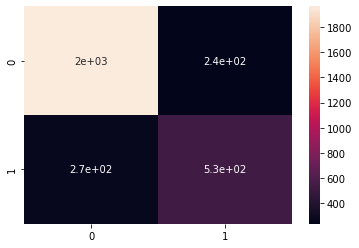

In [48]:
y_predict_testing = classify.predict(x_testing)

#Heatmap for the confusion matrix!
cm2 = confusion_matrix(y_testing, y_predict_testing)
sns.heatmap(cm2, annot=True) #FN(Full Negative) and FP(Full Positive) seems to similar with each other!

**Classification Report**


In [49]:
print(classification_report(y_testing, y_predict_testing))


              precision    recall  f1-score   support

           0       0.88      0.89      0.89      2201
           1       0.69      0.66      0.68       799

    accuracy                           0.83      3000
   macro avg       0.78      0.78      0.78      3000
weighted avg       0.83      0.83      0.83      3000



### **E2. Output/Calculations**
See the calculations and outputs listed above.

### **E3. Code**
See code listed above.

### **F1. Results**
Reduced Logistic Regression Equation Model: y = -4.381 + -0.311*X<sub>1</sub> + 0.0344*X<sub>2</sub> + -0.9144*X<sub>3</sub> + -0.4591*X<sub>4</sub> + -0.0100*X<sub>5</sub> + 0.843*X<sub>6</sub>+ -2.0981*X<sub>7</sub> + -3.1186*X<sub>8</sub> + 0.5248*X<sub>9</sub> + -0.9319*X<sub>10</sub> -0.3146*X<sub>11</sub> -0.4808*X<sub>12</sub> + 0.6269*X<sub>13</sub>

### **F2. Recommendations**
It's critical for stakeholders to understand that some of our predictor variables and our goal variable, Churn, are inversely related. This means that as a consumer subscribes to more services from the organization, they are less likely to leave or churn from the company.
Clearly, it is in the company's best interests to provide additional services to customers and improve their overall experience by supporting them in understanding all of the options available to them as a subscriber, not just mobile phone service. 
Individuals with contracts are less likely to leave the organization, thus we propose spending more on marketing efforts for contract usage and internet services.
There is a direct linear relationship between bandwidth used annually and telecom company tenure. Clients that stay with the telecom firm for more than 5 years may be eligible for a discount in bandwidth usage and their bandwidth limits may be extended depends on how long they stay at the company. 


### **G. Video**
https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=85e134a6-0f92-4e29-b81e-adc8015110c4

### **H.  Sources for Third-Party Code**
* Pitsillides91. (n.d.). Python-Tutorials/Introduction to ML - Logistic Regression Example at master · Pitsillides91/Python-Tutorials. Retrieved from https://github.com/Pitsillides91/Python-Tutorials/tree/master/Introduction to ML - Logistic Regression Example
* D. (2019, September 26). How to Perform Logistic Regression in Python(Step by Step). Data Science. https://www.datarmatics.com/data-science/how-to-perform-logistic-regression-in-pythonstep-by-step/

### **I.  Sources**

* StatQuest: Logistic Regression. (2018, March 5). YouTube. https://www.youtube.com/watch?v=yIYKR4sgzI8&ab_channel=StatQuestwithJoshStarmer
* Statistics 101: Logistic Regression, An Introduction. (2015, March 9). YouTube. https://www.youtube.com/watch?v=zAULhNrnuL4&ab_channel=BrandonFoltz
